In [3]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

2.15.0
1.26.4


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
print(os.listdir("../dataset"))

['.DS_Store', 'data']


In [6]:
print(os.listdir("../dataset/data"))

['test', 'train']


In [7]:
print(os.listdir("../dataset/data/train"))

['infected', 'notinfected']


In [8]:
IMG_SIZE = 224

In [9]:
def load_images(folder):

    data = []
    labels = []

    classes = ['infected', 'notinfected']

    for label in classes:

        path = os.path.join(folder, label)

        class_num = 1 if label == 'infected' else 0

        for img in os.listdir(path):

            try:
                img_path = os.path.join(path, img)

                image = cv2.imread(img_path)

                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

                data.append(image)

                labels.append(class_num)

            except Exception as e:
                print("Error:", e)

    return np.array(data), np.array(labels)

In [10]:
train_folder = "../dataset/data/train"

train_data, train_labels = load_images(train_folder)

In [11]:
print(train_data.shape)
print(train_labels.shape)

(1924, 224, 224, 3)
(1924,)


In [12]:
train_data = train_data / 255.0

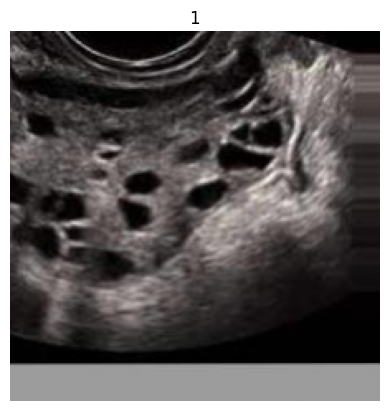

In [13]:
plt.imshow(train_data[0])
plt.title(train_labels[0])
plt.axis("off")
plt.show()

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    train_data,
    train_labels,
    test_size=0.2,
    random_state=42
)

In [16]:
print(X_train.shape)
print(X_test.shape)

(1539, 224, 224, 3)
(385, 224, 224, 3)


In [17]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

2026-05-13 02:24:25.126002: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-13 02:24:25.126038: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-13 02:24:25.126041: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-13 02:24:25.126066: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-13 02:24:25.126077: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10


2026-05-13 02:24:27.826819: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


49/49 [==============================] - 9s 129ms/step - loss: 3.6434 - accuracy: 0.5302 - val_loss: 0.3922 - val_accuracy: 0.8390
Epoch 2/10
49/49 [==============================] - 5s 92ms/step - loss: 0.8170 - accuracy: 0.7908 - val_loss: 0.1261 - val_accuracy: 0.9455
Epoch 3/10
49/49 [==============================] - 4s 91ms/step - loss: 0.1672 - accuracy: 0.9474 - val_loss: 0.1833 - val_accuracy: 0.9403
Epoch 4/10
49/49 [==============================] - 5s 99ms/step - loss: 0.2325 - accuracy: 0.9558 - val_loss: 0.0342 - val_accuracy: 0.9818
Epoch 5/10
49/49 [==============================] - 5s 98ms/step - loss: 0.2176 - accuracy: 0.9643 - val_loss: 0.2755 - val_accuracy: 0.9688
Epoch 6/10
49/49 [==============================] - 4s 92ms/step - loss: 0.5014 - accuracy: 0.9662 - val_loss: 0.1091 - val_accuracy: 0.9844
Epoch 7/10
49/49 [==============================] - 5s 94ms/step - loss: 0.3799 - accuracy: 0.9766 - val_loss: 0.6647 - val_accuracy: 0.9584
Epoch 8/10
49/49 [=====

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

13/13 [==============================] - 0s 21ms/step - loss: 0.9231 - accuracy: 0.9818
Test Accuracy: 0.9818181991577148


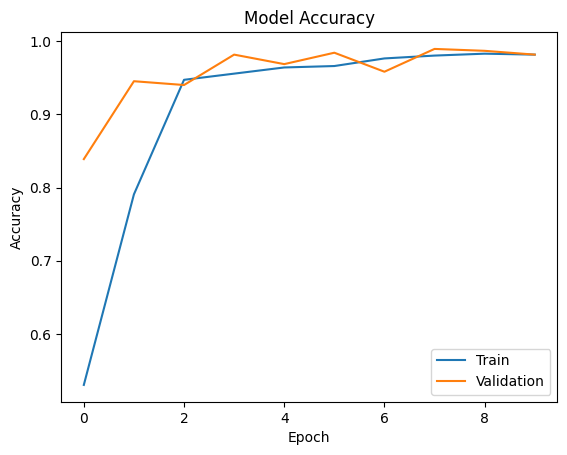

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

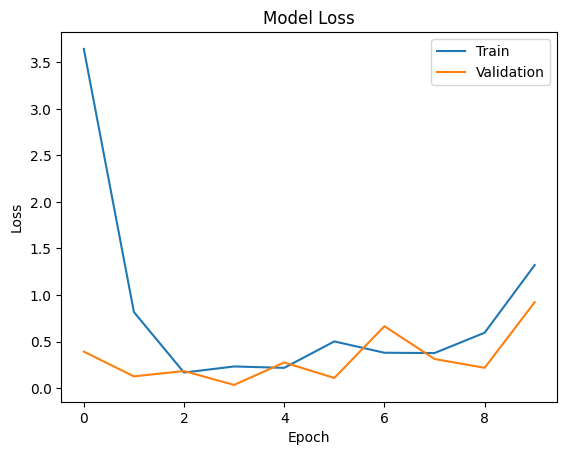

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

In [25]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [26]:
base_model.trainable = False

In [27]:
transfer_model = Sequential()

transfer_model.add(base_model)

transfer_model.add(GlobalAveragePooling2D())

transfer_model.add(Dense(128, activation='relu'))

transfer_model.add(Dropout(0.5))

transfer_model.add(Dense(1, activation='sigmoid'))

In [28]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
transfer_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2422081 (9.24 MB)
Trainable params: 1640

In [30]:
history_transfer = transfer_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
49/49 [==============================] - 8s 131ms/step - loss: 0.0935 - accuracy: 0.9578 - val_loss: 0.0015 - val_accuracy: 1.0000
Epoch 2/5
49/49 [==============================] - 5s 94ms/step - loss: 0.0022 - accuracy: 0.9987 - val_loss: 2.7707e-04 - val_accuracy: 1.0000
Epoch 3/5
49/49 [==============================] - 5s 93ms/step - loss: 5.0107e-04 - accuracy: 1.0000 - val_loss: 1.6978e-04 - val_accuracy: 1.0000
Epoch 4/5
49/49 [==============================] - 4s 92ms/step - loss: 3.3259e-04 - accuracy: 1.0000 - val_loss: 1.4130e-04 - val_accuracy: 1.0000
Epoch 5/5
49/49 [==============================] - 4s 91ms/step - loss: 2.7775e-04 - accuracy: 1.0000 - val_loss: 1.2044e-04 - val_accuracy: 1.0000


In [31]:
loss, accuracy = transfer_model.evaluate(X_test, y_test)

print("Transfer Learning Accuracy:", accuracy)

13/13 [==============================] - 1s 67ms/step - loss: 1.2044e-04 - accuracy: 1.0000
Transfer Learning Accuracy: 1.0


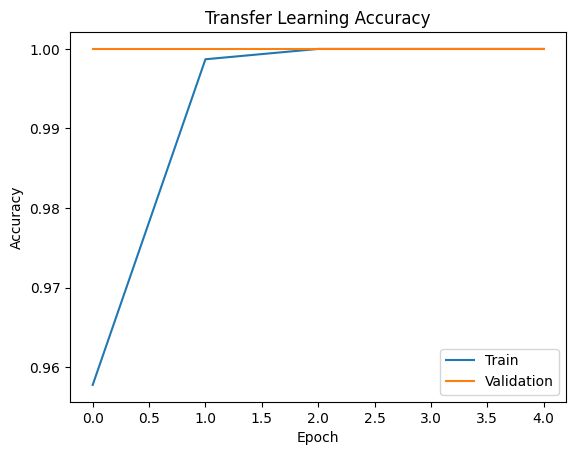

In [32]:
plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])

plt.title('Transfer Learning Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [33]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [34]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Get base MobileNet model
    base_model = model.layers[0]

    # Last convolution layer
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Create a model that maps input image to:
    # 1. last conv layer output
    # 2. final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            last_conv_layer.output,
            model.output
        ]
    )

    # Compute gradients
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    # Gradient of loss wrt conv outputs
    grads = tape.gradient(loss, conv_outputs)

    # Mean intensity
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Feature maps
    conv_outputs = conv_outputs[0]

    # Weighted feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [35]:
last_conv_layer_name = "Conv_1"

In [36]:
img = X_test[0]

img_array = np.expand_dims(img, axis=0)

In [37]:
base_model = transfer_model.layers[0]

In [38]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# Input layer
inputs = Input(shape=(224,224,3))

# Base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)

# Freeze layers
base_model.trainable = False

# Add custom layers
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

outputs = Dense(1, activation='sigmoid')(x)

# Final model
functional_model = Model(inputs, outputs)

In [39]:
functional_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
history_func = functional_model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/2
49/49 [==============================] - 6s 107ms/step - loss: 0.1356 - accuracy: 0.9487 - val_loss: 0.0010 - val_accuracy: 1.0000
Epoch 2/2
49/49 [==============================] - 4s 91ms/step - loss: 0.0025 - accuracy: 1.0000 - val_loss: 4.4092e-04 - val_accuracy: 1.0000


In [41]:
img = X_test[0]

img_array = np.expand_dims(img, axis=0)

In [42]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [43]:
heatmap = make_gradcam_heatmap(
    img_array,
    functional_model,
    "Conv_1"
)

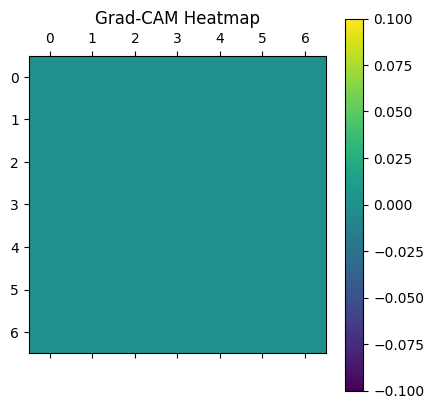

In [44]:
plt.matshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.colorbar()

plt.show()

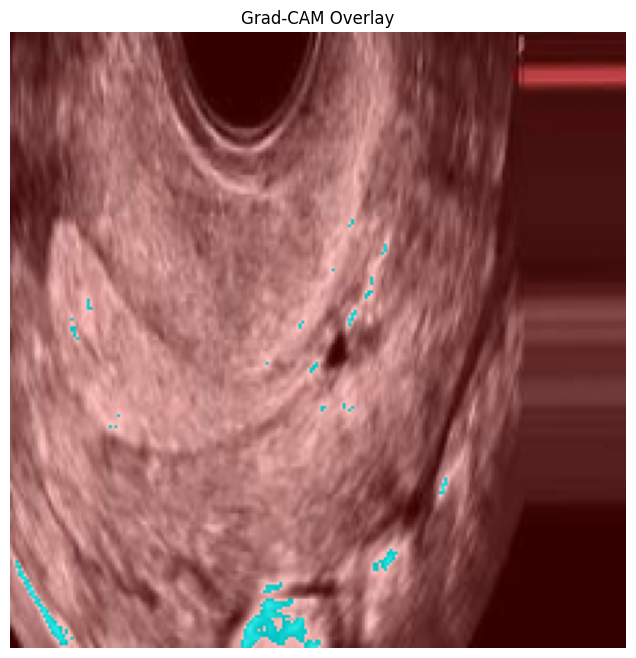

In [45]:
heatmap = cv2.resize(heatmap, (224,224))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = heatmap * 0.4 + (img * 255)

plt.figure(figsize=(8,8))

plt.imshow(superimposed_img.astype("uint8"))

plt.axis("off")

plt.title("Grad-CAM Overlay")

plt.show()

In [46]:
functional_model.save("../models/pcos_model.h5")

/opt/anaconda3/envs/pcos_clean/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [47]:
def predict_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (224,224))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = functional_model.predict(img)

    if prediction[0][0] > 0.5:
        print("Infected")
    else:
        print("Not Infected")

In [48]:
functional_model.save("../models/pcos_model.h5")

In [49]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [50]:
y_pred_prob = functional_model.predict(X_test)

13/13 [==============================] - 1s 81ms/step


In [51]:
history_func = functional_model.fit(
    X_train,
    y_train,
    epochs=1,
    batch_size=32,
    validation_data=(X_test, y_test)
)

49/49 [==============================] - 5s 96ms/step - loss: 9.0648e-04 - accuracy: 1.0000 - val_loss: 1.7539e-04 - val_accuracy: 1.0000


In [52]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [53]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[226   0]
 [  0 159]]


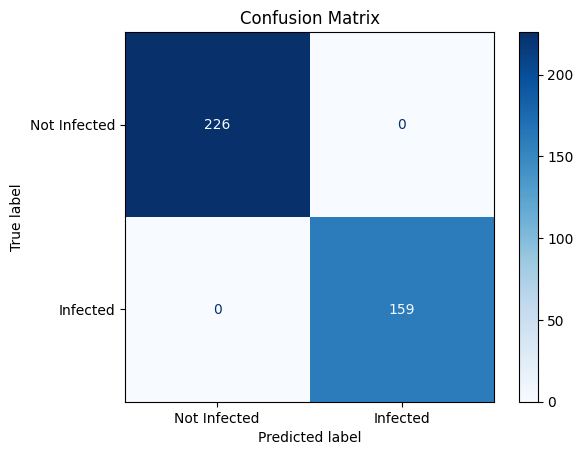

In [54]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Infected", "Infected"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00       159

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385



In [56]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [57]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

In [58]:
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 1.0


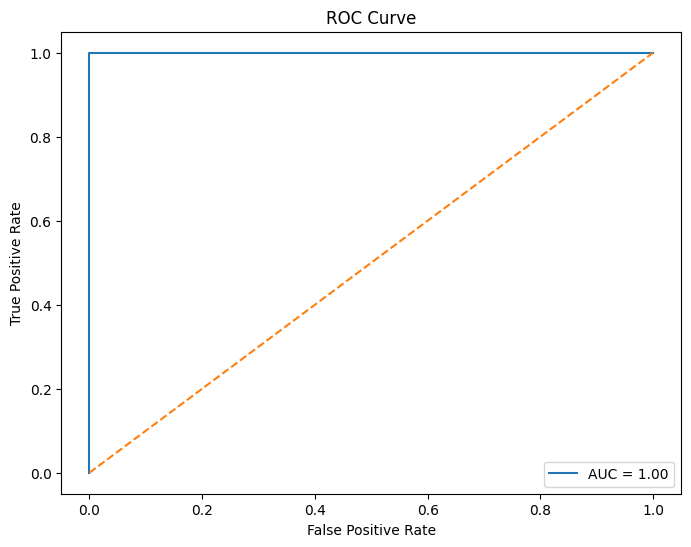

In [59]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()